In [13]:
### Importação das bibliotecas necessárias

import numpy as np
import pandas as pd

from pandas import Series, DataFrame

import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


In [31]:
### Importação do ficheiro csv

passengers= pd.read_csv("titanic_v2.csv", sep=",")

In [ ]:
### Colunas do dataset

passengers.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
### Transformação da variável categórica ("Sex") para variável númerica 

passengers["Sex"] =passengers["Sex"].map({"female": 0, "male": 1})
passengers.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


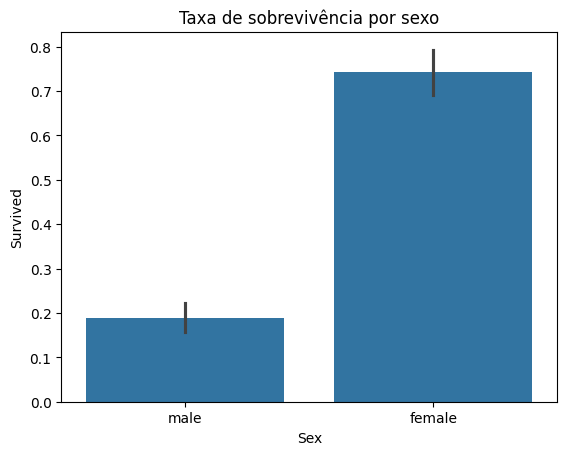

In [ ]:
### Taxa de sobrevivência por sexo 

passengers= pd.read_csv("titanic_v2.csv", sep=",")
sns.barplot(data=passengers, x="Sex", y="Survived")
plt.title("Taxa de sobrevivência por sexo")
plt.show()

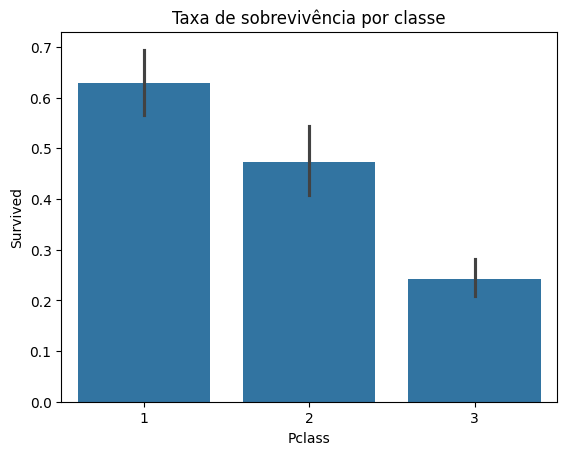

In [ ]:
### Taxa de sobrevivência por classe

sns.barplot(data=passengers, x="Pclass", y="Survived")
plt.title("Taxa de sobrevivência por classe")
plt.show()

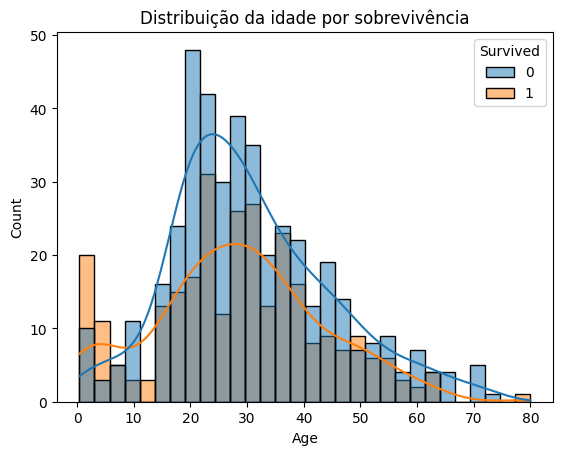

In [ ]:
### Distribuição por idade da sobrevivência

sns.histplot(data=passengers, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Distribuição da idade por sobrevivência")
plt.show()

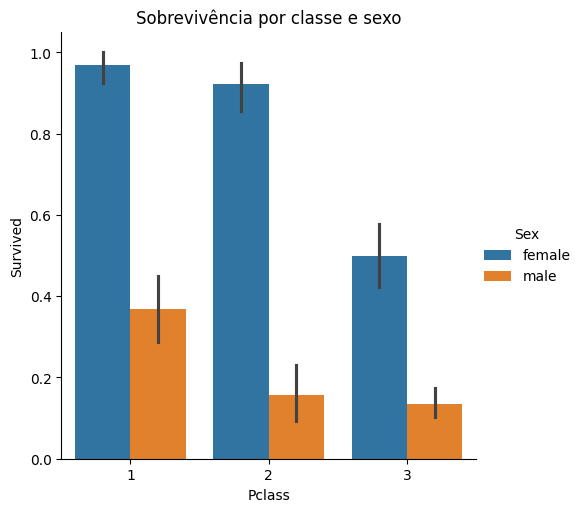

In [ ]:
### Sobrevivência por classe e sexo

sns.catplot(data=passengers, x="Pclass", y="Survived", hue="Sex", kind="bar")
plt.title("Sobrevivência por classe e sexo")
plt.show()


In [ ]:
### Colunas

cols = ["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
passengers = passengers[cols].copy()

In [ ]:
# Subsituição de nulos

passengers["Age"].fillna(passengers["Age"].median(), inplace=True)
passengers["Embarked"].fillna(passengers["Embarked"].mode()[0], inplace=True)


C:\Users\ana_m\AppData\Local\Temp\ipykernel_4780\3983678324.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  passengers["Age"].fillna(passengers["Age"].median(), inplace=True)
C:\Users\ana_m\AppData\Local\Temp\ipykernel_4780\3983678324.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [ ]:
### Dummies

passengers = pd.get_dummies(passengers, drop_first=True, dtype=float)

In [ ]:
### Modelo de regressão logística, previsões e accuracy

if passengers["Sex"].dtype == "object":
    passengers["Sex"] = passengers["Sex"].map({"male": 0, "female": 1})

    # Eliminar nulos
    passengers_model = passengers[["Survived", "Pclass", "Sex"]].dropna()

    # Baralhar os dados
    passengers_model = passengers_model.sample(frac=1, random_state=42).reset_index(drop=True)

    # Divisão dos dados
    split = int(0.7 * len(passengers_model))
    train = passengers_model.iloc[:split]
    test = passengers_model.iloc[split:]

    #Modelo de regressão logistica ajustado
    model = smf.logit("Survived ~ Pclass + Sex", data=train).fit()
    print("\nResumo do modelo:")
    print(model.summary())

    # Previsões
    y_pred_prob = model.predict(test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    y_test = test["Survived"]

    # Matriz de confusão
    conf_matrix = pd.crosstab(y_test, y_pred)

    print("\nMatriz de Confusão:")
    print(conf_matrix)

    # Precisão
    accuracy = (y_test == y_pred).mean()
    print("\nTaxa Global de Acerto:", round(accuracy, 4))


Optimization terminated successfully.
         Current function value: 0.456946
         Iterations 6

Resumo do modelo:
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  623
Model:                          Logit   Df Residuals:                      620
Method:                           MLE   Df Model:                            2
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3175
Time:                        17:13:06   Log-Likelihood:                -284.68
converged:                       True   LL-Null:                       -417.09
Covariance Type:            nonrobust   LLR p-value:                 3.127e-58
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8631      0.294      2.939      0.003       0.287       1.439
Pclass    

## Conclusões

- O modelo acertou 78% das previsões no conjunto de teste.
- Observa-se que a variável "Sex" tem forte influência na sobrevivência.
- Para melhorar, podemos incluir variáveis contínuas como Age e Fare.